In [5]:
from pyspark.sql import SparkSession

# 1. Aseguramos la sesión activa en el Kernel actual
spark = SparkSession.builder.appName("Storytelling_Final").getOrCreate()

# 2. Traemos los datos nativos persistidos en formato Parquet desde tu carpeta real
ruta_datos = "./Prueba"
df_historico = spark.read.parquet(ruta_datos)

# 3. Contamos cuántos registros totales logramos recuperar para el análisis
total_registros = df_historico.count()
print(f"ÉXITO: Conexión establecida. Hemos recuperado {total_registros} productos del histórico etiquetados con KMeans.")

ÉXITO: Conexión establecida. Hemos recuperado 5594 productos del histórico etiquetados con KMeans.


In [8]:
import pyspark.sql.functions as F

# 1. Calculamos el total de SKUs
total_sku = df_historico.count()

# 2. Aplicamos LIMPIEZA PROFUNDA: Mayúsculas + Quitar Acentos + Eliminar ' y .
df_limpio = df_historico.withColumn(
    "marca_limpia",
    F.trim(
        F.regexp_replace(
            F.translate(F.upper(F.col("marca")), "ÁÉÍÓÚÜ", "AEIOUU"),
            "['\\.]", "" # Borra apóstrofes y puntos de la marca
        )
    )
)

# 3. Volvemos a construir el KPI agrupando por la marca 100% pulida
kpi_estrategico = df_limpio.groupBy("marca_limpia") \
    .agg(
        F.count("marca_limpia").alias("Cantidad_SKUs"),
        F.round((F.count("marca_limpia") / total_sku) * 100, 2).alias("Participacion_Catalogo_Porcentaje")
    ).orderBy(F.desc("Cantidad_SKUs"))

# 4. Mostramos el resultado total limpio
total_filas_marcas = kpi_estrategico.count()
kpi_estrategico.show(total_filas_marcas, truncate=False)

+------------------------+-------------+---------------------------------+
|marca_limpia            |Cantidad_SKUs|Participacion_Catalogo_Porcentaje|
+------------------------+-------------+---------------------------------+
|GENERICA                |767          |13.71                            |
|GOURMET                 |298          |5.33                             |
|OTRA                    |274          |4.9                              |
|CUISINE & CO            |274          |4.9                              |
|SOPROLE                 |240          |4.29                             |
|LIDER                   |238          |4.25                             |
|NUESTRA COCINA          |185          |3.31                             |
|COLUN                   |159          |2.84                             |
|MAGGI                   |126          |2.25                             |
|CAROZZI                 |100          |1.79                             |
|LONCOLECHE              

/tmp/ipykernel_3839/2534684571.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


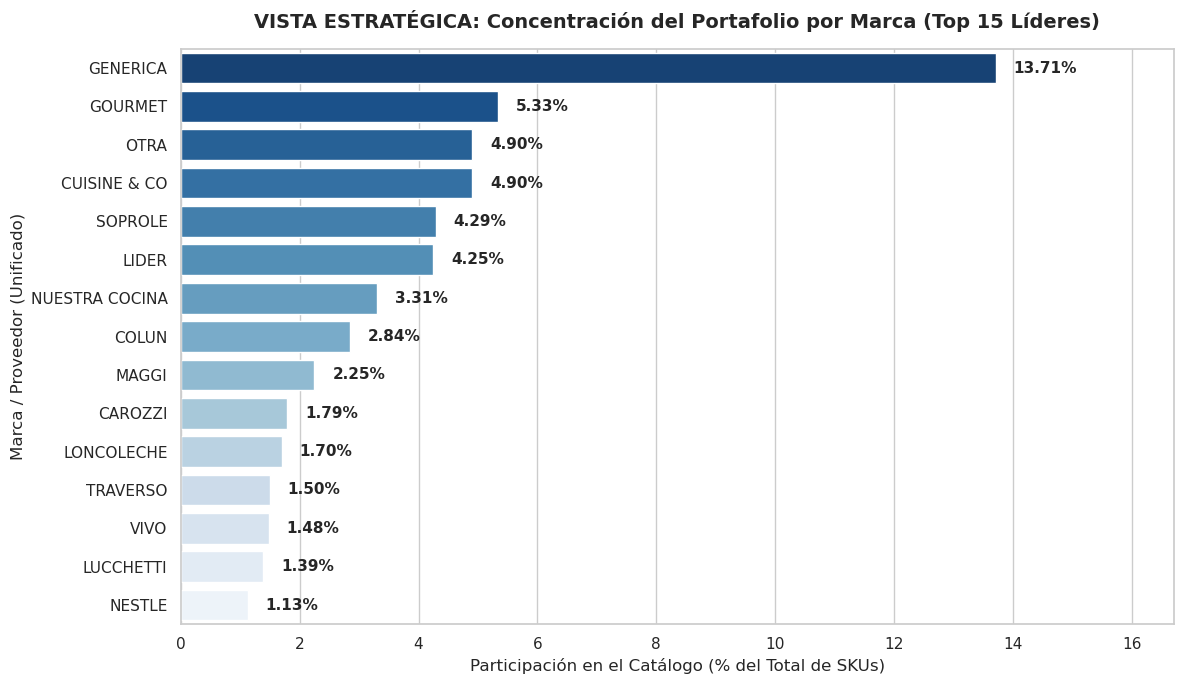

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark.sql.functions as F

# 1. Procesamiento en Spark con la LIMPIEZA PROFUNDA incorporada
total_sku = df_historico.count()

# Unificamos mayúsculas, quitamos acentos, puntos y apóstrofes
df_limpio = df_historico.withColumn(
    "marca_limpia",
    F.trim(
        F.regexp_replace(
            F.translate(F.upper(F.col("marca")), "ÁÉÍÓÚÜ", "AEIOUU"),
            "['\\.]", ""
        )
    )
)

# Calculamos el KPI estratégico sobre las marcas pulidas
kpi_estrategico = df_limpio.groupBy("marca_limpia") \
    .agg(F.round((F.count("marca_limpia") / total_sku) * 100, 2).alias("Participacion_Porcentaje")) \
    .orderBy(F.desc("Participacion_Porcentaje"))

# 2. Conversión a Pandas - TRUCO CLAVE: Filtramos solo el TOP 15 para que sea legible
df_est_pandas = kpi_estrategico.limit(15).toPandas()

# 3. Diseño del Gráfico Estratégico
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Creamos gráfico de barras horizontales
ax = sns.barplot(
    x="Participacion_Porcentaje",
    y="marca_limpia",
    data=df_est_pandas,
    palette="Blues_r" # Degradado de azul (de más oscuro a más claro)
)

# Añadimos las etiquetas de porcentaje al final de cada barra (Comillas corregidas)
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"{width:.2f}%",
        (width + 0.3, p.get_y() + p.get_height() / 2),
        va='center', 
        ha='left', 
        fontsize=11, 
        fontweight='bold'
    )

# Configuración de títulos y etiquetas limpias
plt.title("VISTA ESTRATÉGICA: Concentración del Portafolio por Marca (Top 15 Líderes)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Participación en el Catálogo (% del Total de SKUs)", fontsize=12)
plt.ylabel("Marca / Proveedor (Unificado)", fontsize=12)

# Damos un margen a la derecha para que el texto de los porcentajes no se corte
plt.xlim(0, df_est_pandas["Participacion_Porcentaje"].max() + 3) 

plt.tight_layout()
plt.show()

In [10]:
import pyspark.sql.functions as F

# 1. Aplicamos Limpieza Profunda a las marcas antes de agruparlas
df_limpio = df_historico.withColumn(
    "marca_limpia",
    F.trim(
        F.regexp_replace(
            F.translate(F.upper(F.col("marca")), "ÁÉÍÓÚÜ", "AEIOUU"),
            "['\\.]", ""
        )
    )
)

# 2. Construimos la Matriz de Volatilidad usando tu columna real: "precio"
kpi_tactico = df_limpio.groupBy("marca_limpia") \
    .agg(
        F.round(F.min("precio"), 2).alias("Precio_Minimo"),
        F.round(F.avg("precio"), 2).alias("Precio_Promedio"),
        F.round(F.max("precio"), 2).alias("Precio_Maximo"),
        F.round(F.stddev("precio"), 2).alias("Desviacion_Estandar_Precios")
    ).orderBy(F.desc("Desviacion_Estandar_Precios"))

print("=== [KPI TÁCTICO] - MATRIZ DE VOLATILIDAD Y COMPETITIVIDAD DE PRECIOS ===")

# 3. Mostramos las marcas ordenadas por las que tienen mayor dispersión de precios
kpi_tactico.show(20, truncate=False)

=== [KPI TÁCTICO] - MATRIZ DE VOLATILIDAD Y COMPETITIVIDAD DE PRECIOS ===
+--------------+-------------+---------------+-------------+---------------------------+
|marca_limpia  |Precio_Minimo|Precio_Promedio|Precio_Maximo|Desviacion_Estandar_Precios|
+--------------+-------------+---------------+-------------+---------------------------+
|CALAN         |1590.0       |35804.44       |102000.0     |49660.35                   |
|COLUN         |250.0        |9471.68        |82000.0      |19089.89                   |
|NESTLE        |360.0        |9637.46        |81890.0      |18422.22                   |
|QUILLAYES     |1250.0       |8926.82        |63000.0      |17558.67                   |
|SURLAT        |1190.0       |9804.67        |65100.0      |16736.25                   |
|LECHE SUR     |1650.0       |12265.0        |22880.0      |15011.88                   |
|NATUREZZA     |290.0        |10018.18       |31000.0      |13215.12                   |
|KRYZPO        |870.0        |12286.

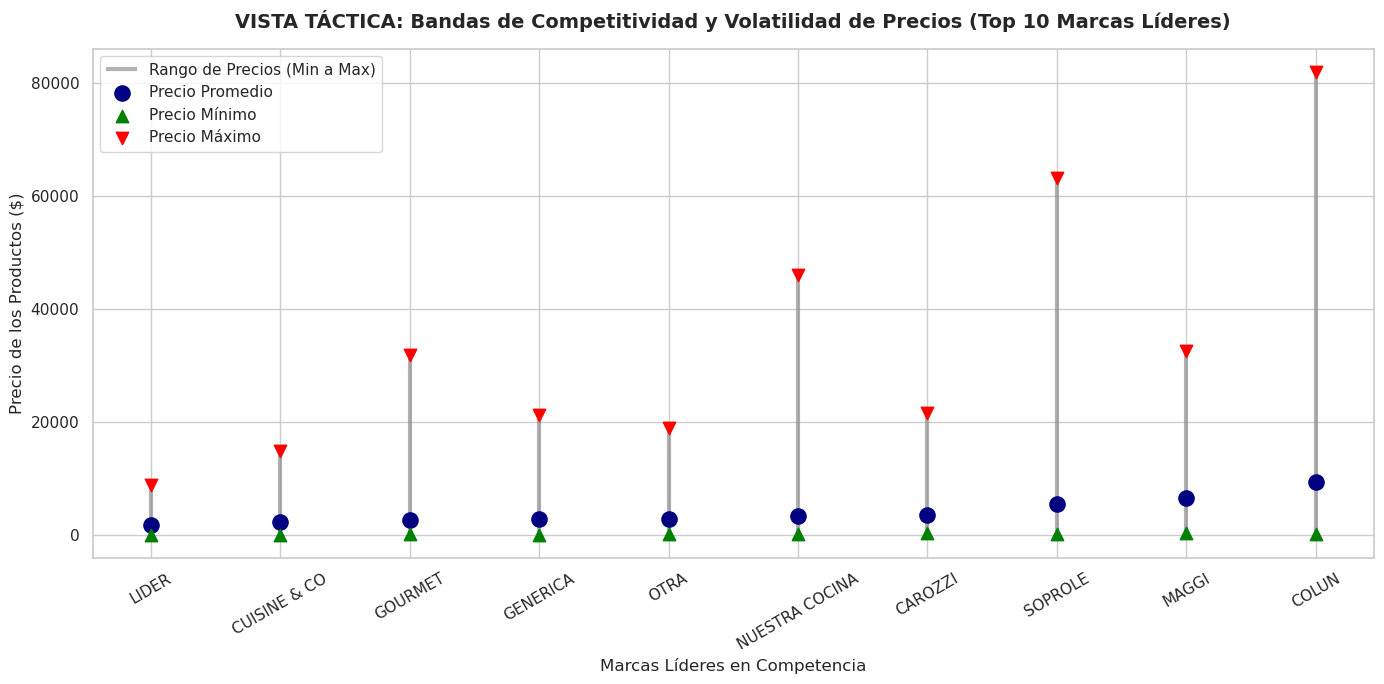

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark.sql.functions as F

# 1. Procesamiento en Spark con Limpieza Profunda de Marcas
# Unificamos mayúsculas, quitamos acentos, puntos y apóstrofes
df_limpio = df_historico.withColumn(
    "marca_limpia",
    F.trim(
        F.regexp_replace(
            F.translate(F.upper(F.col("marca")), "ÁÉÍÓÚÜ", "AEIOUU"),
            "['\\.]", ""
        )
    )
)

# Primero identificamos cuáles son las 10 marcas con más SKUs (las líderes)
top_10_marcas = df_limpio.groupBy("marca_limpia") \
    .count() \
    .orderBy(F.desc("count")) \
    .limit(10) \
    .select("marca_limpia") \
    .rdd.flatMap(lambda x: x).collect()

# Filtramos el set de datos solo para esas 10 marcas y calculamos sus métricas con "precio"
kpi_tactico = df_limpio.filter(F.col("marca_limpia").isin(top_10_marcas)) \
    .groupBy("marca_limpia") \
    .agg(
        F.round(F.min("precio"), 2).alias("Precio_Minimo"),
        F.round(F.avg("precio"), 2).alias("Precio_Promedio"),
        F.round(F.max("precio"), 2).alias("Precio_Maximo")
    ).orderBy("Precio_Promedio")

# 2. Conversión a Pandas
df_tac_pandas = kpi_tactico.toPandas()

# 3. Diseño del Gráfico Táctico de Bandas de Precios
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Dibujamos las líneas de rango mínimo y máximo
plt.vlines(
    x=df_tac_pandas['marca_limpia'], 
    ymin=df_tac_pandas['Precio_Minimo'], 
    ymax=df_tac_pandas['Precio_Maximo'],
    colors='gray', 
    alpha=0.6, 
    linewidth=3, 
    label="Rango de Precios (Min a Max)"
)

# Dibujamos los puntos de control (Promedio, Mínimo y Máximo) con las comillas corregidas
plt.scatter(df_tac_pandas['marca_limpia'], df_tac_pandas['Precio_Promedio'], color='navy', s=120, label="Precio Promedio", zorder=3)
plt.scatter(df_tac_pandas['marca_limpia'], df_tac_pandas['Precio_Minimo'], color='green', marker='^', s=80, label="Precio Mínimo", zorder=3)
plt.scatter(df_tac_pandas['marca_limpia'], df_tac_pandas['Precio_Maximo'], color='red', marker='v', s=80, label="Precio Máximo", zorder=3)

# Configuración de textos y etiquetas ajustadas a tus datos de Retail
plt.title("VISTA TÁCTICA: Bandas de Competitividad y Volatilidad de Precios (Top 10 Marcas Líderes)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Marcas Líderes en Competencia", fontsize=12)
plt.ylabel("Precio de los Productos ($)", fontsize=12)

plt.xticks(rotation=30, fontsize=11)
plt.legend(loc="upper left", frameon=True, fontsize=11)
plt.tight_layout()
plt.show()

In [12]:
import pyspark.sql.functions as F
from pyspark.sql.window import Window

# 1. Aplicamos Limpieza Profunda a las marcas
df_limpio = df_historico.withColumn(
    "marca_limpia",
    F.trim(
        F.regexp_replace(
            F.translate(F.upper(F.col("marca")), "ÁÉÍÓÚÜ", "AEIOUU"),
            "['\\.]", ""
        )
    )
)

# 2. Usamos Ventanas (Window) para calcular el promedio y desviación estándar de PRECIO por CLÚSTER (prediction)
window_spec = Window.partitionBy("prediction")

df_con_metricas = df_limpio \
    .withColumn("Precio_Promedio_Cluster", F.avg("precio").over(window_spec)) \
    .withColumn("Desviacion_Cluster", F.stddev("precio").over(window_spec))

# 3. FILTRO OPERACIONAL: Alerta si el precio se aleja demasiado del comportamiento de su clúster
# (Precio > Promedio + 2 veces la Desviación Estándar = Producto sospechosamente caro para su categoría)
kpi_operacional_alertas = df_con_metricas \
    .filter(F.col("precio") > (F.col("Precio_Promedio_Cluster") + (F.col("Desviacion_Cluster") * 2))) \
    .select(
        F.col("marca_limpia").alias("Marca"), 
        "supermercado", 
        "categoria", 
        F.col("precio").alias("Precio_Detectado"), 
        F.col("prediction").alias("Cluster_Asignado"),
        F.round("Precio_Promedio_Cluster", 2).alias("Promedio_Esperado")
    ).orderBy(F.desc("Precio_Detectado"))

# 4. Contamos y mostramos las alertas reales
total_alertas = kpi_operacional_alertas.count()
print(f"=== [KPI OPERACIONAL] - ALERTAS CRÍTICAS DE PRECIOS ANÓMALOS POR CLÚSTER ===")
print(f"⚠️ Total de productos que requieren revisión del Supervisor: {total_alertas} de un total de {df_historico.count()}")
print("-" * 80)

kpi_operacional_alertas.show(15, truncate=False)

=== [KPI OPERACIONAL] - ALERTAS CRÍTICAS DE PRECIOS ANÓMALOS POR CLÚSTER ===
⚠️ Total de productos que requieren revisión del Supervisor: 257 de un total de 5594
--------------------------------------------------------------------------------
+---------+------------+------------------------------+----------------+----------------+-----------------+
|Marca    |supermercado|categoria                     |Precio_Detectado|Cluster_Asignado|Promedio_Esperado|
+---------+------------+------------------------------+----------------+----------------+-----------------+
|CALAN    |Unimarc     |Lácteos, Huevos y Refrigerados|102000.0        |0               |4080.7           |
|CALAN    |Unimarc     |Lácteos, Huevos y Refrigerados|102000.0        |0               |4080.7           |
|CALAN    |Unimarc     |Lácteos, Huevos y Refrigerados|102000.0        |0               |4080.7           |
|COLUN    |Unimarc     |Lácteos, Huevos y Refrigerados|82000.0         |0               |4080.7           |
|

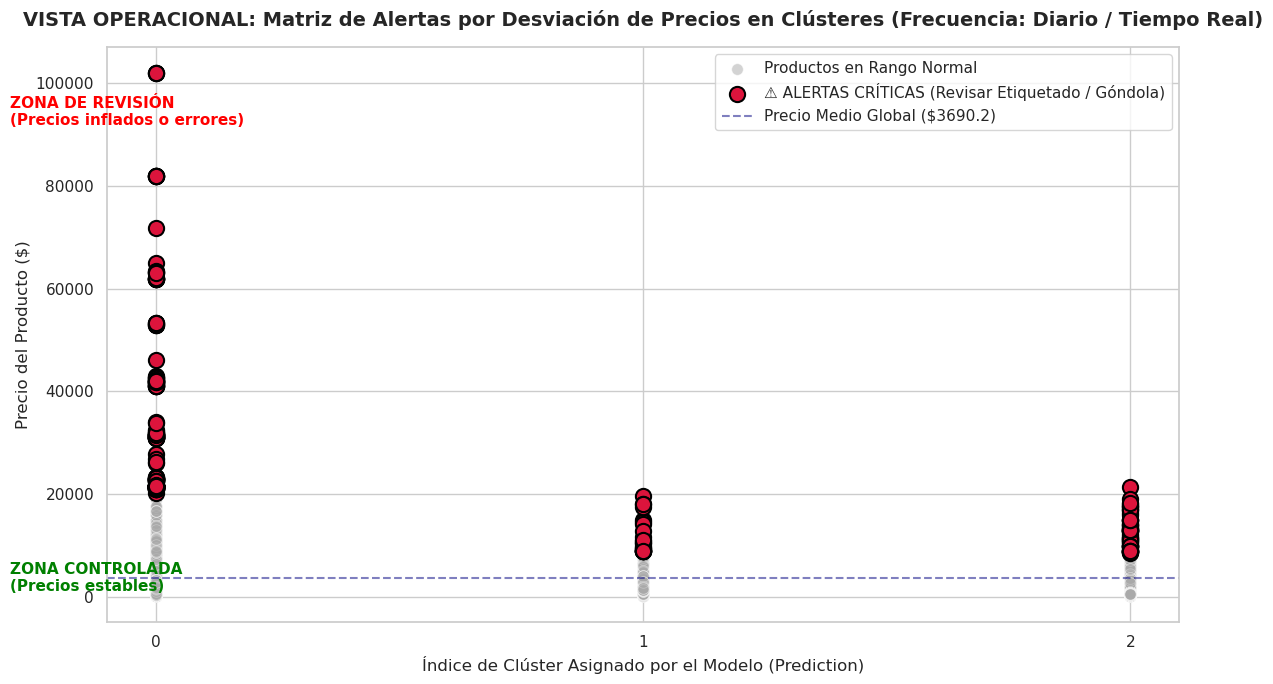

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark.sql.functions as F
from pyspark.sql.window import Window

# 1. Procesamiento en Spark con tus datos reales y cálculo de umbrales
df_limpio = df_historico.withColumn(
    "marca_limpia",
    F.trim(
        F.regexp_replace(
            F.translate(F.upper(F.col("marca")), "ÁÉÍÓÚÜ", "AEIOUU"),
            "['\\.]", ""
        )
    )
)

# Calculamos estadísticas por clúster (prediction) para detectar los desvíos
window_spec = Window.partitionBy("prediction")
df_con_limites = df_limpio \
    .withColumn("Precio_Promedio", F.avg("precio").over(window_spec)) \
    .withColumn("Desviacion", F.stddev("precio").over(window_spec)) \
    .withColumn("Umbral_Alerta", F.col("Precio_Promedio") + (F.col("Desviacion") * 2))

# Pasamos todo a Pandas para graficar de forma segura
df_op_pandas = df_con_limites.select("prediction", "precio", "Umbral_Alerta", "marca_limpia").toPandas()

# 2. Diseño del Gráfico Operacional Adaptado
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Graficamos todos los productos en gris oscuro (comportamiento normal)
sns.scatterplot(
    x="prediction",
    y="precio",
    data=df_op_pandas,
    alpha=0.5,
    s=70,
    color="darkgray",
    label="Productos en Rango Normal"
)

# Filtramos en Pandas para aislar y resaltar en ROJO la zona de peligro operacional (Precios anómalos)
zona_peligro = df_op_pandas[df_op_pandas['precio'] > df_op_pandas['Umbral_Alerta']]

sns.scatterplot(
    x="prediction",
    y="precio",
    data=zona_peligro,
    color="crimson",
    s=120,
    label="⚠️ ALERTAS CRÍTICAS (Revisar Etiquetado / Góndola)",
    edgecolor="black",
    linewidth=1.5,
    zorder=5
)

# Dibujamos líneas horizontales que marquen visualmente el precio promedio general como referencia operativa
precio_medio_global = df_op_pandas['precio'].mean()
plt.axhline(y=precio_medio_global, color='navy', linestyle='--', alpha=0.5, linewidth=1.5, label=f"Precio Medio Global (${round(precio_medio_global, 1)})")

# Textos guía estratégicos para el Supervisor de Tienda
plt.text(-0.3, df_op_pandas['precio'].max() * 0.9, "ZONA DE REVISIÓN\n(Precios inflados o errores)", color="red", weight="bold", fontsize=11)
plt.text(-0.3, precio_medio_global * 0.3, "ZONA CONTROLADA\n(Precios estables)", color="green", weight="bold", fontsize=11)

# Ajustes de etiquetas adaptados al modelo KMeans de Retail
plt.title("VISTA OPERACIONAL: Matriz de Alertas por Desviación de Precios en Clústeres (Frecuencia: Diario / Tiempo Real)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Índice de Clúster Asignado por el Modelo (Prediction)", fontsize=12)
plt.ylabel("Precio del Producto ($)", fontsize=12)

# Forzamos que el eje X muestre solo números enteros de clústeres existentes
plt.xticks(sorted(df_op_pandas['prediction'].unique()))

plt.legend(loc="upper right", frameon=True, fontsize=11)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

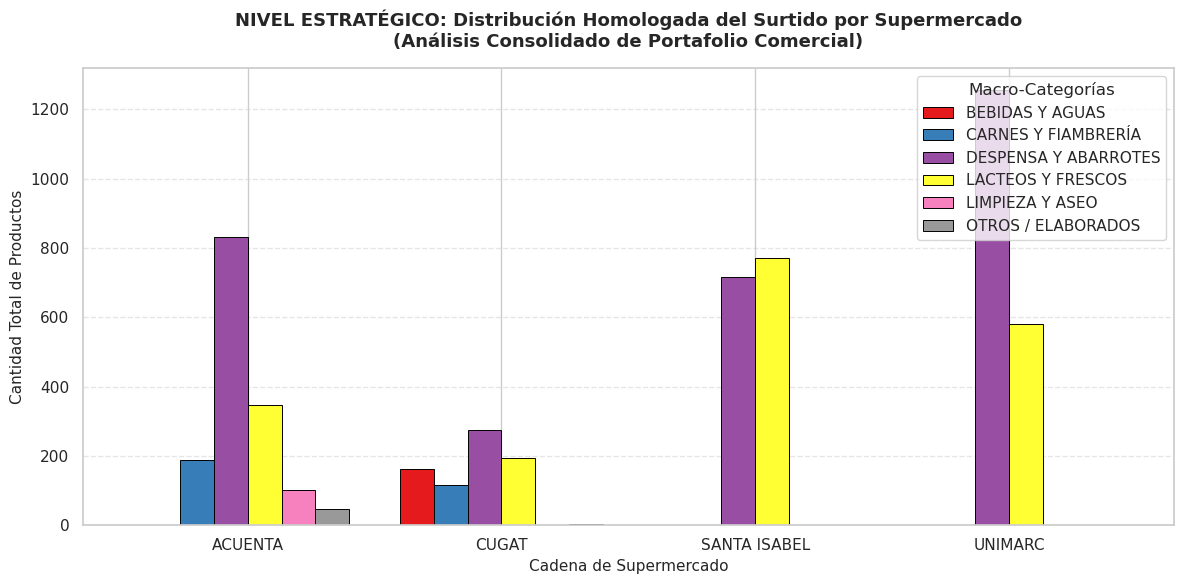

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pyspark.sql.functions as F

# 1. Estandarización inicial de textos
df_base = df_historico \
    .withColumn("supermercado", F.trim(F.translate(F.upper(F.col("supermercado")), "ÁÉÍÓÚÜ", "AEIOUU"))) \
    .withColumn("categoria", F.trim(F.translate(F.upper(F.col("categoria")), "ÁÉÍÓÚÜ", "AEIOUU")))

# 2. JUNTAMOS LAS CATEGORÍAS (Homologación basada en image_c3cb00.png e image_c3cadc.png)
df_final_limpio = df_base.withColumn(
    "categoria_limpia",
    F.when(
        F.col("categoria").isin(
            "ACEITES", "ADEREZOS Y CONDIMENTOS", "ARROZ", "ARROZ, LEGUMBRES Y SEMILLAS", 
            "AZUCARES", "CONSERVAS", "CONSERVAS Y ENLATADOS", "DESPENSA", "DESPENSA GENERAL", 
            "PASTAS", "PASTAS FIDEOS Y SALSAS", "SALSAS", "LEGUMBRES", "HARINAS", "HARINAS LEVADURAS Y GRASAS"
        ), "DESPENSA Y ABARROTES"
    )
    .when(
        F.col("categoria").isin(
            "LACTEOS", "LACTEOS Y CONGELADOS", "LACTEOS, HUEVOS Y REFRIGERADOS", 
            "LACTEOS/FIAMBRERIA", "LECHE EN POLVO", "LECHES LIQUIDAS Y CREMAS", 
            "MANTEQUILLAS Y MARGARINAS", "QUESOS", "YOGHURT Y POSTRES", "HUEVOS", "OTROS FRESCOS"
        ), "LACTEOS Y FRESCOS"
    )
    .when(
        F.col("categoria").isin(
            "AVES", "CARNICERIA", "CERDO", "FIAMBRERIA", "FIAMBRERIA EMBUTIDOS Y QUESOS", 
            "FIAMBRERIA Y EMBUTIDOS", "PESCADOS Y MARISCOS"
        ), "CARNES Y FIAMBRERÍA"
    )
    .when(
        F.col("categoria").isin(
            "AGUA CON GAS", "AGUA SIN GAS", "BEBIDAS", "BEBIDAS JUGOS Y AGUAS", "BEBIDAS LACTEAS Y VEGETALES"
        ), "BEBIDAS Y AGUAS"
    )
    .when(
        F.col("categoria").isin("ASEO", "LIMPIEZA"), "LIMPIEZA Y ASEO"
    )
    .otherwise("OTROS / ELABORADOS")
)

# 3. Agrupamos por Supermercado y la nueva Categoría Limpia
df_estrategico_pd = df_final_limpio.groupBy("supermercado", "categoria_limpia").count().toPandas()
df_pivot = df_estrategico_pd.pivot(index='supermercado', columns='categoria_limpia', values='count').fillna(0)

# 4. Diseño del Gráfico Consolidado
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Graficamos barras agrupadas lado a lado limpias
ax = df_pivot.plot(kind='bar', figsize=(12, 6), width=0.8, colormap='Set1', edgecolor='black', linewidth=0.7)

plt.title("NIVEL ESTRATÉGICO: Distribución Homologada del Surtido por Supermercado\n(Análisis Consolidado de Portafolio Comercial)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Cadena de Supermercado", fontsize=11)
plt.ylabel("Cantidad Total de Productos", fontsize=11)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Leyenda compacta y elegante
plt.legend(title="Macro-Categorías", loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3839/1499437163.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


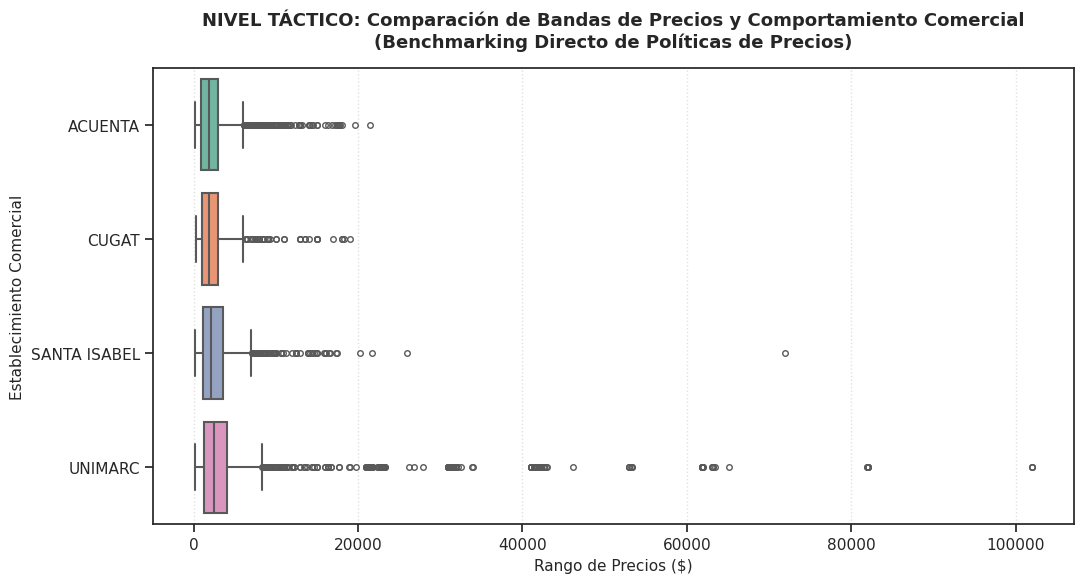

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark.sql.functions as F

# 1. Limpieza obligatoria antes de procesar
df_final_limpio = df_historico \
    .withColumn("marca", F.trim(F.regexp_replace(F.translate(F.upper(F.col("marca")), "ÁÉÍÓÚÜ", "AEIOUU"), "['\\.]", ""))) \
    .withColumn("supermercado", F.trim(F.translate(F.upper(F.col("supermercado")), "ÁÉÍÓÚÜ", "AEIOUU")))

# 2. Extraemos las columnas clave directamente a Pandas
df_tactico_pd = df_final_limpio.select("supermercado", "precio").toPandas()

# 3. Diseño del Gráfico
plt.figure(figsize=(11, 6))
sns.set_theme(style="ticks")

orden_supermercados = df_tactico_pd.groupby("supermercado")["precio"].median().sort_values().index

sns.boxplot(
    x="precio",
    y="supermercado",
    data=df_tactico_pd,
    order=orden_supermercados,
    palette="Set2",
    linewidth=1.5,
    fliersize=4
)

plt.title("NIVEL TÁCTICO: Comparación de Bandas de Precios y Comportamiento Comercial\n(Benchmarking Directo de Políticas de Precios)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Rango de Precios ($)", fontsize=11)
plt.ylabel("Establecimiento Comercial", fontsize=11)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3839/3729667405.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot_op = sns.barplot(


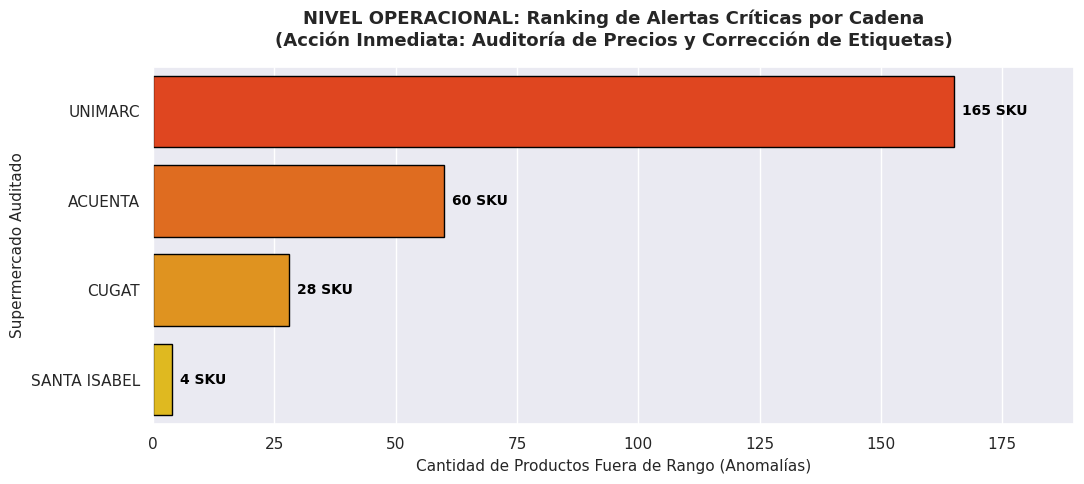

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark.sql.functions as F
from pyspark.sql.window import Window

# 1. Limpieza obligatoria antes de procesar
df_final_limpio = df_historico \
    .withColumn("marca", F.trim(F.regexp_replace(F.translate(F.upper(F.col("marca")), "ÁÉÍÓÚÜ", "AEIOUU"), "['\\.]", ""))) \
    .withColumn("supermercado", F.trim(F.translate(F.upper(F.col("supermercado")), "ÁÉÍÓÚÜ", "AEIOUU")))

# 2. Regla operativa: Identificar desvíos extremos en los datos reales
window_spec = Window.partitionBy("prediction")
df_alertas_op = df_final_limpio \
    .withColumn("Promedio", F.avg("precio").over(window_spec)) \
    .withColumn("Desviacion", F.stddev("precio").over(window_spec)) \
    .withColumn("Limite_Superior", F.col("Promedio") + (F.col("Desviacion") * 2)) \
    .filter(F.col("precio") > F.col("Limite_Superior"))

df_ranking_alertas_pd = df_alertas_op.groupBy("supermercado").count().orderBy(F.desc("count")).toPandas()

# 3. Diseño del Gráfico
plt.figure(figsize=(11, 5))
sns.set_theme(style="darkgrid")

barplot_op = sns.barplot(
    x="count",
    y="supermercado",
    data=df_ranking_alertas_pd,
    palette="autumn",
    edgecolor="black",
    linewidth=1
)

for index, value in enumerate(df_ranking_alertas_pd['count']):
    barplot_op.text(value + (df_ranking_alertas_pd['count'].max() * 0.01), index, f"{int(value)} SKU", 
                    va='center', ha='left', weight='bold', color='black', fontsize=10)

plt.title("NIVEL OPERACIONAL: Ranking de Alertas Críticas por Cadena\n(Acción Inmediata: Auditoría de Precios y Corrección de Etiquetas)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Cantidad de Productos Fuera de Rango (Anomalías)", fontsize=11)
plt.ylabel("Supermercado Auditado", fontsize=11)
plt.xlim(0, df_ranking_alertas_pd["count"].max() * 1.15)
plt.tight_layout()
plt.show()